# Imports

In [389]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.optimize import minimize_scalar

In [390]:

def fidelity(T, R_dark, R0, tau):
    S = R0 * tau * (1 - np.exp(-T / tau))
    D = R_dark * T

    lam_dark = D
    lam_bright = D + S

    if D == 0:
        nth = 1
    else:
        nth = int(np.floor(S / np.log(lam_bright / lam_dark)) + 1)

    p_dark_correct = poisson.cdf(nth - 1, lam_dark)
    p_bright_correct = 1 - poisson.cdf(nth - 1, lam_bright)

    return 0.5 * (p_dark_correct + p_bright_correct), nth

def optimal_integration_time(R_dark, R0, tau, Tmax):
    def objective(T):
        F, _ = fidelity(T, R_dark, R0, tau)
        return -F

    result = minimize_scalar(objective, bounds=(0, Tmax), method="bounded")
    Topt = result.x
    Fopt, nth = fidelity(Topt, R_dark, R0, tau)

    return Topt, Fopt, nth

In [391]:

def simulate_readout_counts(
    tlist,
    N,
    R_dark,
    R0,
    tau,
    bright=True,
    rng=None,
    return_per_shot=False,
):
    """
    Simulate photon counts in time bins for repeated readout experiments.

    Parameters
    ----------
    tlist : array_like
        Time-bin edges, shape (n_bins + 1,). Bin i is [tlist[i], tlist[i+1]).
        Units should be consistent with R_dark, R0, and tau.
    N : int
        Number of repeated readouts.
    R_dark : float
        Constant dark/background count rate.
    R0 : float
        Initial true photon rate at t = 0 for the bright state.
    tau : float
        Exponential decay time constant of the true photon rate.
    bright : bool, default=True
        If True, simulate bright-state readout with signal + dark counts.
        If False, simulate dark-state readout with dark counts only.
    rng : np.random.Generator or None
        Optional NumPy random generator.
    return_per_shot : bool, default=False
        If True, return counts for each shot with shape (N, n_bins).
        If False, return summed histogram over all N shots with shape (n_bins,).

    Returns
    -------
    counts : ndarray
        Photon counts per bin. Shape is (n_bins,) if return_per_shot=False,
        otherwise (N, n_bins).
    mean_counts_per_shot : ndarray
        Expected counts per bin for one readout.
    """

    if rng is None:
        rng = np.random.default_rng()

    tlist = np.asarray(tlist, dtype=float)

    if tlist.ndim != 1:
        raise ValueError("tlist must be a 1D array of time-bin edges.")

    if len(tlist) < 2:
        raise ValueError("tlist must contain at least two time-bin edges.")

    if np.any(np.diff(tlist) <= 0):
        raise ValueError("tlist must be strictly increasing.")

    t0 = tlist[:-1]
    t1 = tlist[1:]
    dt = t1 - t0

    # Dark counts per bin per readout
    dark_mean = R_dark * dt

    # True signal photons per bin per readout
    if bright:
        signal_mean = R0 * tau * (np.exp(-t0 / tau) - np.exp(-t1 / tau))
    else:
        signal_mean = np.zeros_like(dt)

    mean_counts_per_shot = dark_mean + signal_mean

    if return_per_shot:
        counts = rng.poisson(mean_counts_per_shot, size=(N, len(dt)))
    else:
        # Sum over N independent readouts.
        # Equivalent to simulating each readout and summing, because
        # sums of independent Poisson variables are Poisson.
        counts = rng.poisson(N * mean_counts_per_shot)

    return counts, mean_counts_per_shot

In [392]:
def readout_classification_weights(
    tlist,
    N=1,
    R_dark=0.0,
    R0=0.0,
    tau=1.0,
    bright=True,
    return_per_shot=False,
    method="integrated",
):
    """
    Return log-likelihood-ratio weights for binned photon-count readout.

    Parameters
    ----------
    tlist : array_like
        Time-bin edges, shape (n_bins + 1,).
        Bin i is [tlist[i], tlist[i+1]).
    N : int, default=1
        Number of repeated readouts being summed.
        This does not change the per-count weights, but it does scale the
        classification offset.
    R_dark : float
        Constant dark/background count rate.
    R0 : float
        Initial true photon rate for bright-state fluorescence.
    tau : float
        Exponential decay time constant.
    method : {"integrated", "center"}, default="integrated"
        "integrated" uses the exact binned Poisson likelihood.
        "center" uses w(t) evaluated at the bin center.

    Returns
    -------
    weights : ndarray
        Per-bin log-likelihood-ratio weights, shape (n_bins,).
        The classification statistic is roughly counts @ weights - offset.
    offset : float
        The no-click penalty term for N repeated readouts.
        For equal priors, decide bright if

            counts @ weights - offset > 0

        where counts is the summed count histogram over N readouts.
    info : dict
        Extra useful arrays, including bin centers and expected signal/dark
        counts per shot.
    """

    tlist = np.asarray(tlist, dtype=float)

    if tlist.ndim != 1:
        raise ValueError("tlist must be a 1D array of time-bin edges.")

    if len(tlist) < 2:
        raise ValueError("tlist must contain at least two bin edges.")

    if np.any(np.diff(tlist) <= 0):
        raise ValueError("tlist must be strictly increasing.")

    if R_dark < 0:
        raise ValueError("R_dark must be nonnegative.")

    if R0 < 0:
        raise ValueError("R0 must be nonnegative.")

    if tau <= 0:
        raise ValueError("tau must be positive.")


    t0 = tlist[:-1]
    t1 = tlist[1:]
    dt = t1 - t0
    t_centers = 0.5 * (t0 + t1)

    # Expected dark counts in each bin for one readout.
    mu_dark = R_dark * dt

    # Expected true signal photons in each bin for one bright-state readout.
    mu_sig = R0 * tau * (np.exp(-t0 / tau) - np.exp(-t1 / tau))

    if method == "integrated":
        # Exact binned Poisson LLR weight:
        # w_i = log(mu_bright_i / mu_dark_i)
        #     = log(1 + mu_sig_i / mu_dark_i)
        with np.errstate(divide="ignore", invalid="ignore"):
            weights = np.log1p(mu_sig / mu_dark)

    elif method == "center":
        # Narrow-bin approximation to the continuous-time-tag weight:
        # w(t_i) = log(1 + (R0 / R_dark) exp(-t_i / tau)).
        if R_dark == 0:
            weights = np.full_like(t_centers, np.inf)
        else:
            weights = np.log1p((R0 / R_dark) * np.exp(-t_centers / tau))

    else:
        raise ValueError("method must be 'integrated' or 'center'.")

    # The integral of the excess bright-state rate over the readout window.
    # This is the penalty for the fact that the bright hypothesis predicts
    # more total events than the dark hypothesis.
    signal_counts_per_shot = np.sum(mu_sig)
    offset = signal_counts_per_shot

    info = {
        "t0": t0,
        "t1": t1,
        "dt": dt,
        "t_centers": t_centers,
        "mu_dark_per_shot": mu_dark,
        "mu_signal_per_shot": mu_sig,
        "mu_bright_per_shot": mu_dark + mu_sig,
        "signal_counts_per_shot": signal_counts_per_shot,
    }

    return weights, offset, info

Optimal Integration Time for window:  5.371546135561754e-05
Optimal Fidelity for window:  0.9993887717503254
Optimal Number of True Photons for window:  15
Weighted Bright Classification Rate: 0.99961
Windowed Bright Classification Rate: 0.99925


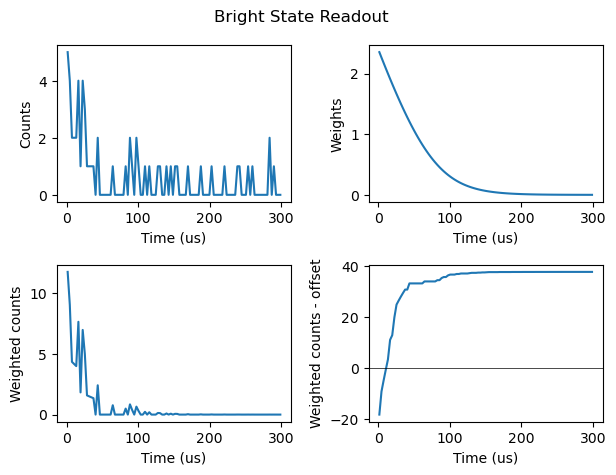

In [402]:
readout_args = {
    "N": 1,
    "R_dark": 100000,
    "R0": 1000_000,
    "tau": 30e-6,
    "bright": True,
    "return_per_shot": False,
}

Tmax = 300e-6
N_reps = 100000

tlist = np.linspace(0, Tmax, 101)  # 100 bins from 0 to 10 us
bin_centers = 0.5 * (tlist[:-1] + tlist[1:])
T_opt, F_opt, nth = optimal_integration_time(readout_args["R_dark"], readout_args["R0"], readout_args["tau"], Tmax)
print("Optimal Integration Time for window: ", T_opt)
print("Optimal Fidelity for window: ", F_opt)
print("Optimal Number of True Photons for window: ", nth)

bright_count_weighted = 0
bright_count_windowed = 0
for i in range(N_reps):
    counts, mean_per_shot = simulate_readout_counts(tlist, **readout_args)
    weights, offset, info = readout_classification_weights(tlist, **readout_args)
    if np.sum(counts*weights)-offset >= 0:
        bright_count_weighted += 1
    if np.sum(np.where(bin_centers < T_opt, counts, 0)) >= nth:
        bright_count_windowed += 1
P_bright_weighted = bright_count_weighted/N_reps
P_bright_windowed = bright_count_windowed/N_reps
print(f"Weighted Bright Classification Rate: {P_bright_weighted}")
print(f"Windowed Bright Classification Rate: {P_bright_windowed}")

fig, ax = plt.subplots(2, 2)
ax[0,0].plot(bin_centers*1e6, counts)
ax[0,0].set_xlabel("Time (us)")
ax[0,0].set_ylabel("Counts")
ax[0,1].plot(bin_centers*1e6, weights)
ax[0,1].set_xlabel("Time (us)")
ax[0,1].set_ylabel("Weights")
ax[1,0].plot(bin_centers*1e6, counts*weights)
ax[1,0].set_xlabel("Time (us)")
ax[1,0].set_ylabel("Weighted counts")
ax[1,1].plot(bin_centers*1e6, np.cumsum(counts*weights)-offset)
ax[1,1].axhline(0, color='black', linewidth=0.5)
ax[1,1].set_xlabel("Time (us)")
ax[1,1].set_ylabel("Weighted counts - offset")
fig.suptitle("Bright State Readout")
plt.tight_layout()
plt.show()


Weighted Dark Classification Rate: 0.99966
Windowed Dark Classification Rate: 0.99941


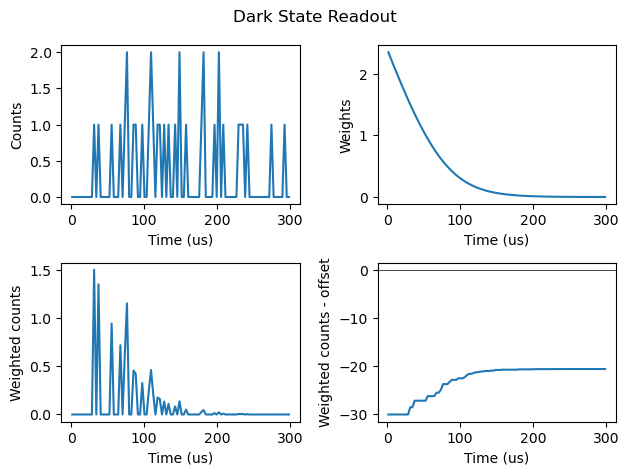

In [403]:
readout_args["bright"] = False

dark_count_weighted = 0
dark_count_windowed = 0
for i in range(N_reps):
    counts, mean_per_shot = simulate_readout_counts(tlist, **readout_args)
    weights, offset, info = readout_classification_weights(tlist, **readout_args)
    if np.sum(counts*weights)-offset >= 0:
        dark_count_weighted += 1
    if np.sum(np.where(bin_centers < T_opt, counts, 0)) >= nth:
        dark_count_windowed += 1
P_dark_weighted = 1-dark_count_weighted/N_reps
P_dark_windowed = 1-dark_count_windowed/N_reps
print(f"Weighted Dark Classification Rate: {P_dark_weighted}")
print(f"Windowed Dark Classification Rate: {P_dark_windowed}")

fig, ax = plt.subplots(2, 2)
ax[0,0].plot(bin_centers*1e6, counts)
ax[0,0].set_xlabel("Time (us)")
ax[0,0].set_ylabel("Counts")
ax[0,1].plot(bin_centers*1e6, weights)
ax[0,1].set_xlabel("Time (us)")
ax[0,1].set_ylabel("Weights")
ax[1,0].plot(bin_centers*1e6, counts*weights)
ax[1,0].set_xlabel("Time (us)")
ax[1,0].set_ylabel("Weighted counts")
ax[1,1].plot(bin_centers*1e6, np.cumsum(counts*weights)-offset)
ax[1,1].axhline(0, color='black', linewidth=0.5)
ax[1,1].set_xlabel("Time (us)")
ax[1,1].set_ylabel("Weighted counts - offset")
fig.suptitle("Dark State Readout")
plt.tight_layout()
plt.show()


In [404]:
fidelity_weighted = (P_bright_weighted + P_dark_weighted)/2
fidelity_windowed = (P_bright_windowed + P_dark_windowed)/2
print(f"Weighted Fidelity: {fidelity_weighted}")
print(f"Windowed Fidelity: {fidelity_windowed}")

Weighted Fidelity: 0.999635
Windowed Fidelity: 0.99933
